# Part 2 — Terrestrial infrared spectrum and blackbody curves

In [1]:
# Parser from parse_MODTRAN.py (provided on Canvas)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



def is_header_line(line: str) -> bool:
    return "RADIANCE(WATTS/CM2-STER" in line

def is_block_terminator(line: str) -> bool:
    return line.strip().startswith("iv")

float_re = re.compile(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eEdD][-+]?\d+)?")

def try_parse_data_line(line: str):
    nums = float_re.findall(line)
    if len(nums) == 12:
        return list(map(lambda x: float(x.replace("D","E").replace("d","e")), nums))
    return None


def read_file(spath):
    text = spath.read_text(errors="ignore").splitlines()
    rows = []
    in_block = False
    skip_next = 0
    for ln in text:
        if is_header_line(ln):
            in_block = True
            skip_next = 2  # the two column header lines immediately after the title
            continue
        if in_block and skip_next > 0:
            skip_next -= 1
            continue
        if in_block:
            if is_block_terminator(ln):
                in_block = False
                continue
            parsed = try_parse_data_line(ln)
            if parsed is not None:
                rows.append(parsed)
    if not rows:
        raise RuntimeError("No radiance rows were detected.")
    cols = [
        "wn_cm1", "wav_um",
        "path_therm_cm1","path_therm_um",
        "surf_emis_cm1","surf_emis_um",
        "surf_refl_cm1","surf_refl_um",
        "total_cm1","total_um",
        "integral_cm1","trans"
    ]
    df = pd.DataFrame(rows, columns=cols)
    df.sort_values("wn_cm1", inplace=True)
    df.drop_duplicates(subset=["wn_cm1"], keep="last", inplace=True)
    df.sort_values("wav_um", inplace=True)
    return df

In [2]:
def BlackBody(w, T):
    # w: wavelength in meters, T: temperature in Kelvin
    # Returns spectral radiance in W m^-2 sr^-1 m^-1
    h = 6.62606957e-34  # joule·s
    c = 2.99792458e8  # Speed of light in m/s
    k = 1.38e-23  # Boltzmann constant in m^2 kg / s^2 / K
    return (2*h*c**2/w**5)*(1/(np.exp((h*c)/(w*k*T)) - 1))

In [3]:
# MODTRAN runs: Midlatitude Summer, no clouds, looking down, CO2 = 427 ppm, CH4 = 1.939 ppm
heights = [0, 20, 40, 60, 80, 100]  # km
spectra = {h: read_file(Path(f"data/height_sweep/h{h}km.txt")) for h in heights}

In [4]:
def to_nm_units(df):
    # Returns (wavelength in nm, total radiance in W m^-2 sr^-1 nm^-1)
    # df has wav_um in µm and total_um in W cm^-2 sr^-1 µm^-1
    wl_nm = df["wav_um"].values*1e3  # µm -> nm
    rad = df["total_um"].values*1e4*1e-3  # cm^-2 -> m^-2, µm^-1 -> nm^-1
    return wl_nm, rad

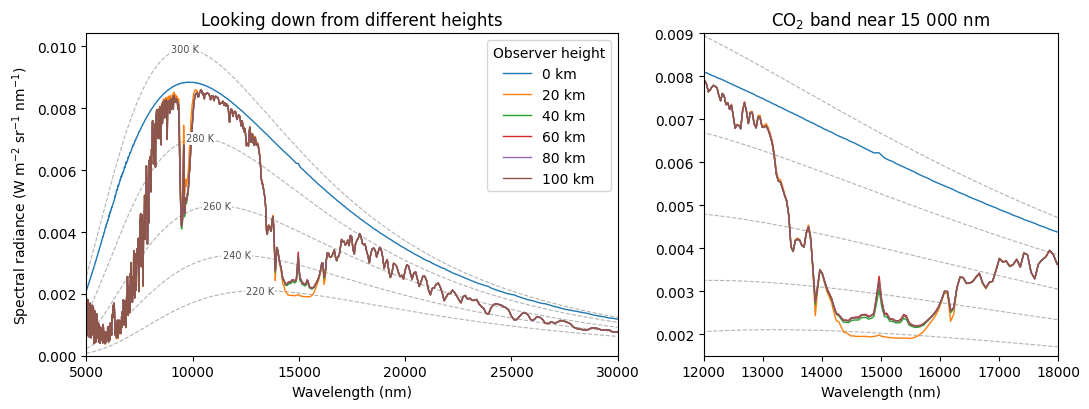

In [5]:
bb_temps = [220, 240, 260, 280, 300]  # K
wl_bb = np.linspace(5000, 30000, 500)  # nm

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 2]})

for ax in (ax_full, ax_zoom):
    for T in bb_temps:
        bb = BlackBody(wl_bb*1e-9, T)*1e-9  # per m -> per nm
        ax.plot(wl_bb, bb, color="0.7", lw=0.8, ls="--")
    for h in heights:
        wl, rad = to_nm_units(spectra[h])
        ax.plot(wl, rad, lw=1.0, label=f"{h} km")
    ax.set_xlabel("Wavelength (nm)")

# label each blackbody curve at its peak (Wien's displacement law)
for T in bb_temps:
    wl_peak = 2.898e6/T  # nm
    ax_full.text(wl_peak, BlackBody(wl_peak*1e-9, T)*1e-9, f"{T} K", fontsize=7, color="0.3",
                 ha="center", va="center", bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax_full.set_xlim(5000, 30000)
ax_full.set_ylim(bottom=0)
ax_full.set_ylabel("Spectral radiance (W m$^{-2}$ sr$^{-1}$ nm$^{-1}$)")
ax_full.set_title("Looking down from different heights")
ax_full.legend(title="Observer height")

# zoom on the CO2 band near 15 µm
ax_zoom.set_xlim(12000, 18000)
ax_zoom.set_ylim(0.0015, 0.009)
ax_zoom.set_title("CO$_2$ band near 15 000 nm")

plt.tight_layout()
plt.savefig("figures/part2_height_sweep.png", dpi=200)
plt.show()